# 03 · Desarrollo del análisis

En este notebook se implementa la estrategia definida para identificar características de los contratos asociadas con una mayor ocurrencia de desviaciones respecto al plan inicial.

El análisis se concentra principalmente en el valor del contrato, el sector y la modalidad de contratación, y estudia su relación con tres posibles desviaciones: adiciones de plazo, ejecución incompleta del valor comprometido y ausencia de liquidación cuando el contrato ya debería haber finalizado.

El dataset original no se modifica. Todas las variables utilizadas durante el análisis se construyen sobre una copia de los datos.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [4]:
ruta_datos = Path("../data/secop_bienes.parquet")

if not ruta_datos.is_file():
    raise FileNotFoundError(
        f"No se encontró el archivo de datos en: {ruta_datos}"
    )

df = pd.read_parquet(ruta_datos)

print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

Filas: 196391
Columnas: 36


## 1. Preparación del conjunto de análisis

Antes de estudiar las relaciones entre las características de los contratos y las desviaciones de interés, se construye un conjunto de datos adecuado para el análisis.

Las transformaciones realizadas en esta sección no modifican el dataset original. Se trabaja sobre una copia y se aplican únicamente los tratamientos necesarios para evitar que diferencias temporales o problemas de calidad previamente identificados afecten las comparaciones posteriores.

In [5]:
df_analisis = df.copy()

### 1.1 Selección del período de análisis

El conjunto de datos contiene contratos firmados entre 2019 y 2025. Debido a que el enunciado advierte que los años no son necesariamente comparables, se analiza primero la evolución anual de algunos indicadores relacionados con la ejecución contractual.

Para cada año se observa la proporción de contratos terminados, liquidados y con días adicionados, además de la mediana del valor contractual. El objetivo de esta comparación es determinar si existen años cuyo estado de ejecución pueda distorsionar el análisis
posterior.

In [8]:
df_analisis["anio_firma"] = df_analisis["fecha_de_firma"].dt.year
contratos_por_anio = (df_analisis["anio_firma"].value_counts().sort_index())

display(contratos_por_anio.to_frame("cantidad_contratos"))

,cantidad_contratos
anio_firma,
2019,16425
2020,20135
2021,24043
2022,28070
2023,32971
2024,34634
2025,40113


In [13]:
estado_normalizado = (df_analisis["estado_contrato"].astype("string").str.strip().str.casefold())
liquidacion_normalizada = (df_analisis["liquidaci_n"].astype("string").str.strip().str.casefold())

df_analisis["terminado"] = estado_normalizado.eq("terminado")
df_analisis["liquidado"] = liquidacion_normalizada.isin(["si", "sí"])
df_analisis["tiene_adicion"] = df_analisis["dias_adicionados"] > 0

resumen_anual = (
    df_analisis
    .groupby("anio_firma")
    .agg(
        contratos=("id_contrato", "size"),
        porcentaje_terminados=("terminado", "mean"),
        porcentaje_liquidados=("liquidado", "mean"),
        porcentaje_con_adicion=("tiene_adicion", "mean"),
        mediana_valor=("valor_del_contrato", "median")
    )
)

columnas_porcentaje = ["porcentaje_terminados", "porcentaje_liquidados", "porcentaje_con_adicion"]
resumen_anual[columnas_porcentaje] *= 100

display(resumen_anual.style.format({
        "porcentaje_terminados": "{:.2f}%",
        "porcentaje_liquidados": "{:.2f}%",
        "porcentaje_con_adicion": "{:.2f}%",
        "mediana_valor": "${:,.0f}"
    })
)

,contratos,porcentaje_terminados,porcentaje_liquidados,porcentaje_con_adicion,mediana_valor
anio_firma,,,,,
2019,16425,17.33%,38.57%,4.18%,"$22,584,160"
2020,20135,21.53%,31.11%,7.76%,"$30,478,395"
2021,24043,27.00%,28.53%,7.43%,"$30,091,316"
2022,28070,29.40%,33.33%,6.69%,"$29,250,000"
2023,32971,31.42%,42.77%,7.84%,"$32,479,498"
2024,34634,32.93%,46.51%,9.35%,"$36,007,123"
2025,40113,26.27%,47.23%,17.29%,"$39,000,000"


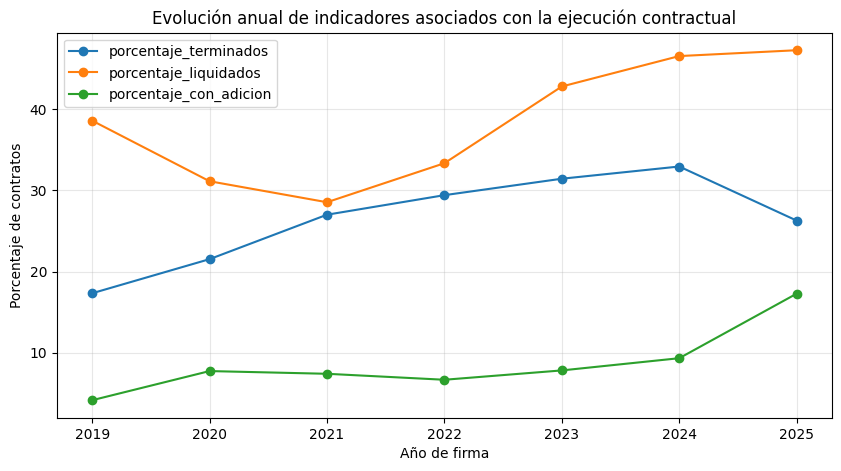

In [14]:
resumen_anual[["porcentaje_terminados", "porcentaje_liquidados", "porcentaje_con_adicion"]].plot(marker="o", figsize=(10, 5))

plt.title("Evolución anual de indicadores asociados con la ejecución contractual")
plt.xlabel("Año de firma")
plt.ylabel("Porcentaje de contratos")
plt.xticks(resumen_anual.index)
plt.grid(alpha=0.3)
plt.show()

Los indicadores presentan diferencias entre los años del conjunto de datos. En particular, los contratos firmados en 2025 muestran un porcentaje de contratos con días adicionados considerablemente mayor al observado en los años anteriores: 17,29 %, frente a 9,35 % en 2024 y valores cercanos al 7 % en varios años previos.

Además, 2025 corresponde al año más reciente del conjunto de datos, por lo que algunos contratos pueden encontrarse en etapas diferentes de su ciclo de ejecución respecto a contratos de años anteriores. Esto puede afectar especialmente variables como la liquidación y el valor efectivamente pagado.

In [16]:
df_periodo = df_analisis.loc[df_analisis["anio_firma"].between(2019, 2024)].copy()

print(f"Contratos en el período de análisis: {len(df_periodo)}")

Contratos en el período de análisis: 156278


Por lo tanto, el análisis principal se realiza sobre los contratos firmados entre 2019 y 2024. Esta selección deja 156.278 contratos disponibles para las comparaciones posteriores. Los registros de 2025 permanecen en el dataset original y únicamente se excluyen del conjunto principal de análisis.

## 2. Construcción de indicadores de desviación

De acuerdo con el problema de negocio, se consideran tres formas principales en las que la ejecución de un contrato puede desviarse del plan inicial: la necesidad de adicionartiempo al plazo establecido, la ejecución incompleta del valor comprometido y la ausencia de liquidación al finalizar el contrato.

Para estudiar estas situaciones se construyen indicadores derivados a partir de las variables originales. Estos indicadores no deben interpretarse automáticamente como irregularidades contractuales; se utilizan como señales observables que permiten comparar grupos de contratos e identificar características asociadas con una mayor frecuencia de desviaciones.

### 2.1 Desviación de plazo

Se considera que un contrato presenta una desviación de plazo cuando registra al menos un día adicionado. Para ello se construye el indicador `desviacion_plazo`, que toma el valor verdadero cuando `dias_adicionados > 0`.

In [17]:
df_periodo["desviacion_plazo"] = (df_periodo["dias_adicionados"] > 0)
resumen_plazo = df_periodo["desviacion_plazo"].value_counts(normalize=True) * 100

display(resumen_plazo.to_frame("porcentaje"))

,porcentaje
desviacion_plazo,
False,92.489666
True,7.510334


En el período 2019–2024, aproximadamente el 7,51 % de los contratos presenta al menos un día adicionado, mientras que el 92.49% no registra extensiones de plazo. Esto muestra que la desviación no es el comportamiento mayoritario, por lo que posteriormente será relevante estudiar si su ocurrencia se concentra en determinadas modalidades, sectores o rangos de valor contractual.

### 2.2 Identificación de contratos con ciclo de ejecución suficientemente avanzado

Las desviaciones relacionadas con ejecución presupuestal y liquidación requieren un tratamiento diferente a las adiciones de plazo. No es apropiado clasificar como desviación a un contrato cuyo período de ejecución todavía no había finalizado al momento de referencia.

Por esta razón, para estos dos indicadores se define como contrato maduro aquel cuya fecha prevista de finalización es igual o anterior al 31 de diciembre de 2024. Además, se excluyen de estas comparaciones los registros previamente identificados con una fecha de finalización anterior a la fecha de inicio.

In [32]:
fecha_corte_cierre = pd.Timestamp("2024-12-31")

df_periodo["contrato_maduro"] = (df_periodo["fecha_de_fin_del_contrato"] <= fecha_corte_cierre)

df_periodo["fecha_contrato_consistente"] = (df_periodo["fecha_de_inicio_del_contrato"].isna() | (df_periodo["fecha_de_fin_del_contrato"] >= df_periodo["fecha_de_inicio_del_contrato"]))

df_cierre = df_periodo.loc[df_periodo["contrato_maduro"] & df_periodo["fecha_contrato_consistente"]].copy()

print(f"Contratos disponibles para análisis de cierre: {len(df_cierre):,}")

Contratos disponibles para análisis de cierre: 151,495


### 2.3 Desviación de liquidación

Para los contratos del subconjunto de cierre se identifica si existe un registro de liquidación. De acuerdo con la revisión inicial de calidad, la variable `liquidaci_n` contiene únicamente las categorías `Si` y `No`, sin valores faltantes.

Se considera como señal de desviación de liquidación un contrato maduro que registra `No`. Esta clasificación se utiliza con fines analíticos y no implica por sí sola que exista un incumplimiento, ya que pueden existir condiciones contractuales que expliquen la ausencia de liquidación.

In [34]:
liquidacion_cierre = (df_cierre["liquidaci_n"].astype("string").str.strip().str.casefold())

df_cierre["desviacion_liquidacion"] = liquidacion_cierre.eq("no")

resumen_liquidacion = (df_cierre["desviacion_liquidacion"].value_counts(normalize=True).mul(100))

display(resumen_liquidacion.to_frame("porcentaje"))

,porcentaje
desviacion_liquidacion,
True,62.767748
False,37.232252


El 62.76% de los contratos analizados presenta una desviación de liquidación, mientras que el 37.23% registra liquidación. Esto indica que, incluso entre los contratos cuyo período previsto de ejecución ya finalizó, la ausencia de liquidación es frecuente. Este resultado se interpreta como una señal para el análisis y no necesariamente como un incumplimiento contractual.

### 2.4 Desviación en la ejecución presupuestal

Para evaluar la ejecución del valor comprometido se compara el valor efectivamente pagado con el valor inicial del contrato. El análisis se realiza únicamente sobre los contratos del subconjunto de cierre, evitando clasificar como desviaciones contratos cuyo
período previsto de ejecución aún no había finalizado.

Los contratos con `valor_del_contrato <= 0` no se utilizan para calcular proporciones de ejecución, dado que no permiten construir una razón interpretable entre el valor pagado y el valor contractual.

In [28]:
df_cierre["valor_contrato_valido"] = (df_cierre["valor_del_contrato"] > 0)

df_cierre["proporcion_ejecutada"] = np.where(df_cierre["valor_contrato_valido"], df_cierre["valor_pagado"] / df_cierre["valor_del_contrato"], np.nan)

In [35]:
df_cierre["proporcion_ejecutada"].describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])

count    151346.000000
mean          0.420733
std           0.484471
min           0.000000
1%            0.000000
5%            0.000000
25%           0.000000
50%           0.000000
75%           1.000000
95%           1.000000
99%           1.000000
max           1.463859
Name: proporcion_ejecutada, dtype: float64

La proporción de ejecución se interpreta como:

- 1.00: el valor pagado coincide con el 100% del valor contractual.
- 0.80: se ha registrado un pago equivalente al 80% del valor contractual.
- 0.00: no se registra valor pagado.
- Valores superiores a 1.00: el valor pagado registrado supera el valor inicial del contrato y requiere una interpretación particular.

In [36]:
df_cierre["desviacion_presupuesto"] = (df_cierre["valor_contrato_valido"] & (df_cierre["valor_pagado"] < df_cierre["valor_del_contrato"]))

resumen_presupuesto = (
    df_cierre.loc[
        df_cierre["valor_contrato_valido"],
        "desviacion_presupuesto"
    ]
    .value_counts(normalize=True)
    .mul(100)
)

display(resumen_presupuesto.to_frame("porcentaje"))

,porcentaje
desviacion_presupuesto,
True,73.717178
False,26.282822


El 73.71% de los contratos analizados presenta una desviación en la ejecución presupuestal, es decir, registra un valor pagado inferior al valor del contrato. En contraste, el 26.28% no presenta esta condición. Esto muestra que la ejecución incompleta del valor comprometido es frecuente dentro del subconjunto analizado y justifica estudiar si se concentra en determinadas características contractuales.

## 3. Construcción de variables para la comparación

### 3.1 Rangos de valor contractual

La distribución del valor contractual presenta una fuerte asimetría y contiene valores extremadamente altos, como se identificó durante el entendimiento inicial. Por esta razón, no se establecen rangos monetarios arbitrarios.

En su lugar, los contratos con valor positivo se dividen en cuatro grupos mediante cuartiles. Esta estrategia permite comparar contratos de menor y mayor valor manteniendo un número aproximadamente similar de observaciones en cada grupo.

In [30]:
mascara_valor = df_periodo["valor_del_contrato"] > 0

df_periodo.loc[
    mascara_valor,
    "rango_valor"
] = pd.qcut(
    df_periodo.loc[mascara_valor, "valor_del_contrato"],
    q=4,
    labels=[
        "Q1 - Menor valor",
        "Q2",
        "Q3",
        "Q4 - Mayor valor"
    ]
)

In [31]:
df_periodo.groupby(
    "rango_valor",
    observed=True
)["valor_del_contrato"].agg(
    cantidad="size",
    minimo="min",
    mediana="median",
    maximo="max"
)

,cantidad,minimo,mediana,maximo
rango_valor,,,,
Q1 - Menor valor,39027,0.01,5000000.0,1.139800e+07
Q2,39154,11399155.31,20180000.0,3.200000e+07
Q3,38919,32000001.00,52489710.0,9.700000e+07
Q4 - Mayor valor,39005,97012053.00,270000000.0,1.285845e+16


Los cuatro grupos contienen aproximadamente 39.000 contratos cada uno. Los tres primeros cuartiles presentan rangos relativamente acotados, mientras que el cuarto concentra los contratos de mayor valor y presenta una amplitud considerable debido a la existencia de
valores extremos.

La clasificación por cuartiles se utilizará principalmente para comparar la frecuencia de las desviaciones entre niveles de valor contractual. Los valores extremos se mantienen, ya que no existe evidencia suficiente para considerarlos errores únicamente por su magnitud.

## 4. Análisis de las desviaciones según las características contractuales

Una vez definidos los indicadores de desviación y las variables que caracterizan los contratos, se analiza si la frecuencia de estas desviaciones cambia entre diferentes grupos.

El análisis comienza con las adiciones de plazo y posteriormente se aplica una lógica similar a las desviaciones de ejecución presupuestal y liquidación. Para cada caso se combinan estadísticos descriptivos, visualizaciones y pruebas de hipótesis que permitan determinar si las diferencias observadas entre los grupos tienen evidencia estadística.

### 4.1 Desviación de plazo según el valor del contrato

En primer lugar, se analiza si la proporción de contratos que presentan adiciones de plazo cambia entre los cuatro rangos de valor contractual definidos anteriormente.

Para cada rango se calcula el número de contratos, la cantidad que presenta al menos un día adicionado y el porcentaje que representa dentro del grupo.

In [37]:
resumen_plazo_valor = (
    df_periodo
    .dropna(subset=["rango_valor"])
    .groupby("rango_valor", observed=True)["desviacion_plazo"]
    .agg(
        cantidad_contratos="size",
        contratos_con_desviacion="sum",
        porcentaje_desviacion=lambda x: x.mean() * 100
    )
)

display(
    resumen_plazo_valor.style.format({
        "porcentaje_desviacion": "{:.2f}%"
    })
)

,cantidad_contratos,contratos_con_desviacion,porcentaje_desviacion
rango_valor,,,
Q1 - Menor valor,39027,1170,3.00%
Q2,39154,2195,5.61%
Q3,38919,3130,8.04%
Q4 - Mayor valor,39005,5234,13.42%


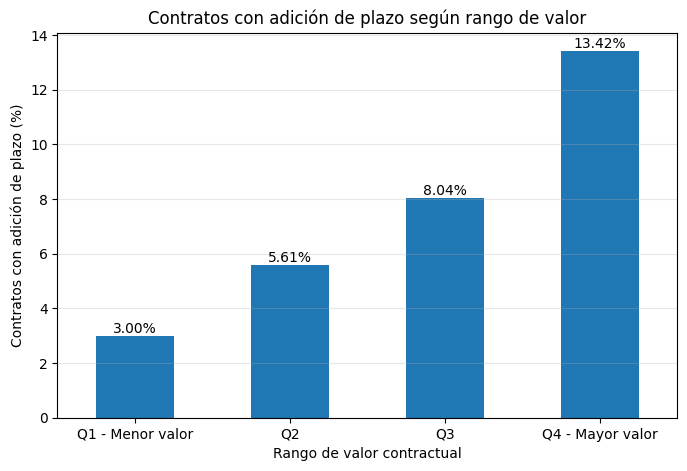

In [38]:
ax = resumen_plazo_valor["porcentaje_desviacion"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Contratos con adición de plazo según rango de valor")
plt.xlabel("Rango de valor contractual")
plt.ylabel("Contratos con adición de plazo (%)")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.show()

Se observa un aumento progresivo en la proporción de contratos con adiciones de plazo a medida que aumenta el rango de valor contractual. Mientras que en el primer cuartil aproximadamente el 3.00% de los contratos presenta esta desviación, la proporción aumenta a 5.61% en Q2, 8.04% en Q3 y 13.42% en el grupo de contratos de mayor valor.

Descriptivamente, estos resultados sugieren que los contratos de mayor valor presentan con mayor frecuencia adiciones de plazo. Sin embargo, se requiere una prueba de hipótesis para determinar si existe evidencia estadística de una asociación entre ambas variables.

#### 4.1.1 Prueba de hipótesis

La comparación descriptiva permite identificar posibles diferencias entre los rangos, pero no permite determinar por sí sola si existe evidencia estadística de una asociación entre el valor contractual y las adiciones de plazo.

Se plantea la siguiente prueba:

- H0: la ocurrencia de adiciones de plazo es independiente del rango de valor del contrato.
- H1: la ocurrencia de adiciones de plazo está asociada con el rango de valor del contrato.

Dado que ambas variables son categóricas, se utiliza una prueba chi-cuadrado de independencia con un nivel de significancia de 0.05.

In [40]:
tabla_plazo_valor = pd.crosstab(df_periodo["rango_valor"], df_periodo["desviacion_plazo"])

display(tabla_plazo_valor)

desviacion_plazo,False,True
rango_valor,,
Q1 - Menor valor,37857,1170
Q2,36959,2195
Q3,35789,3130
Q4 - Mayor valor,33771,5234


In [41]:
chi2, p_value, grados_libertad, esperados = stats.chi2_contingency(tabla_plazo_valor)

print(f"Chi-cuadrado: {chi2:.4f}")
print(f"Grados de libertad: {grados_libertad}")
print(f"p-value: {p_value:.6f}")
print(f"Frecuencia esperada mínima: {esperados.min():.2f}")

Chi-cuadrado: 3323.2354
Grados de libertad: 3
p-value: 0.000000
Frecuencia esperada mínima: 2924.19


Con un nivel de significancia de 0.05, el p-value obtenido es menor que la significancia, por lo que se rechaza la hipótesis nula. Por lo tanto, existe evidencia estadística de una asociación entre el rango de valor contractual y la ocurrencia de adiciones de plazo.

Este resultado es consistente con el análisis descriptivo, en el que la proporción de contratos con adiciones aumenta desde 3.00% en el rango de menor valor hasta 13.42% en el rango de mayor valor. Por tanto, el valor contractual aparece como una característica relevante para continuar evaluando el riesgo de desviaciones de plazo.

### 4.2 Desviación de plazo según el sector

A continuación, se analiza si la proporción de contratos que presentan adiciones de plazo cambia entre los distintos sectores de las entidades contratantes.

Para cada sector se calcula el número de contratos, la cantidad que presenta al menosun día adicionado y el porcentaje que representa dentro del grupo. La categoría No Definido se excluye de esta comparación, ya que durante el entendimiento inicial  se identificó como información no disponible y no representa un sector específico.

In [42]:
df_plazo_sector = df_periodo.loc[df_periodo["sector"] != "No Definido"].copy()

resumen_plazo_sector = (
    df_plazo_sector
    .groupby("sector")["desviacion_plazo"]
    .agg(
        cantidad_contratos="size",
        contratos_con_desviacion="sum",
        porcentaje_desviacion=lambda x: x.mean() * 100
    )
    .sort_values("porcentaje_desviacion", ascending=False)
)

display(resumen_plazo_sector.style.format({"porcentaje_desviacion": "{:.2f}%"}))

,cantidad_contratos,contratos_con_desviacion,porcentaje_desviacion
sector,,,
Información Estadística,421,58,13.78%
Trabajo,11697,1548,13.23%
Minas y Energía,853,107,12.54%
interior,1002,105,10.48%
Tecnologías de la Información y las Comunicaciones,522,52,9.96%
Inclusión Social y Reconciliación,734,70,9.54%
Servicio Público,26957,2211,8.20%
Salud y Protección Social,17453,1419,8.13%
Cultura,2299,186,8.09%


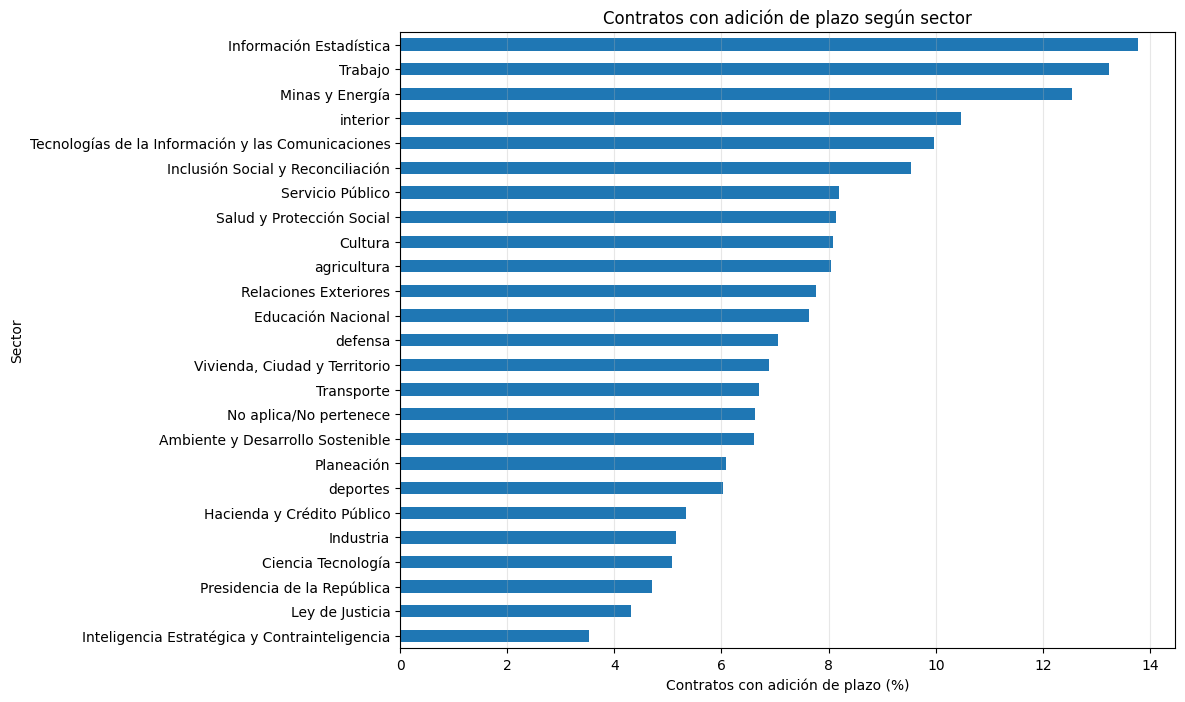

In [44]:
ax = resumen_plazo_sector["porcentaje_desviacion"].sort_values().plot(kind="barh", figsize=(10, 8))

plt.title("Contratos con adición de plazo según sector")
plt.xlabel("Contratos con adición de plazo (%)")
plt.ylabel("Sector")
plt.grid(axis="x", alpha=0.3)

plt.show()

Se observan diferencias en la proporción de contratos con adiciones de plazo entre los sectores. Los mayores porcentajes se presentan en Información Estadística (13.78%), Trabajo (13.23%) y Minas y Energía (12.54%), mientras que los menores se observan en Inteligencia Estratégica y Contrainteligencia (3.53%), Ley de Justicia (4.31.%) y Presidencia de la República (4.71%).

Sin embargo, los porcentajes deben interpretarse junto con la cantidad de contratos de cada sector; por ejemplo, Información Estadística presenta la proporción más alta, pero cuenta con 421 contratos, mientras que Trabajo combina una proporción elevada con un número considerablemente mayor de contratos. Asimismo, sectores como Servicio Público y Salud y Protección Social presentan porcentajes cercanos al 8%, pero concentran una cantidad importante de contratos con desviación.

#### 4.2.1 Prueba de hipótesis

La comparación descriptiva permite observar diferencias en la frecuencia de adiciones de plazo entre sectores. Para determinar si existe evidencia estadística de una dependencia entre ambas variables se plantea:

- H0: la ocurrencia de adiciones de plazo es independiente del sector.
- H1: la ocurrencia de adiciones de plazo está asociada con el sector.

Dado que ambas variables son categóricas, se utiliza una prueba chi-cuadrado de independencia con un nivel de significancia de 0.05.

In [45]:
tabla_plazo_sector = pd.crosstab(df_plazo_sector["sector"], df_plazo_sector["desviacion_plazo"])

display(tabla_plazo_sector)

desviacion_plazo,False,True
sector,,
Ambiente y Desarrollo Sostenible,6368,451
Ciencia Tecnología,355,19
Cultura,2113,186
Educación Nacional,7304,604
Hacienda y Crédito Público,1916,108
Inclusión Social y Reconciliación,664,70
Industria,1326,72
Información Estadística,363,58
Inteligencia Estratégica y Contrainteligencia,82,3


In [46]:
chi2, p_value, grados_libertad, esperados = stats.chi2_contingency(tabla_plazo_sector)

print(f"Chi-cuadrado: {chi2:.4f}")
print(f"Grados de libertad: {grados_libertad}")
print(f"p-value: {p_value:.6f}")
print(f"Frecuencia esperada mínima: {esperados.min():.2f}")

Chi-cuadrado: 1011.0239
Grados de libertad: 24
p-value: 0.000000
Frecuencia esperada mínima: 6.38


Con un nivel de significancia de 0.05, el p-value obtenido es menor que la significancia, por lo que se rechaza la hipótesis nula. Por lo tanto, existe evidencia estadística de una asociación entre el sector y la ocurrencia de adiciones de plazo.

Este resultado respalda las diferencias observadas en el análisis descriptivo. No obstante, la asociación encontrada no implica que pertenecer a un determinado sector cause una adición de plazo, pero indica que la frecuencia de esta desviación no es igual entre todos los sectores.

### 4.3 Desviación de plazo según la modalidad de contratación

Finalmente, se analiza si la frecuencia de las adiciones de plazo cambia según la modalidad utilizada para realizar el proceso de contratación.

Para cada modalidad se calcula la cantidad total de contratos, el número que presenta al menos un día adicionado y el porcentaje correspondiente dentro del grupo.

In [47]:
resumen_plazo_modalidad = (
    df_periodo
    .groupby("modalidad_de_contratacion")["desviacion_plazo"]
    .agg(
        cantidad_contratos="size",
        contratos_con_desviacion="sum",
        porcentaje_desviacion=lambda x: x.mean() * 100
    )
    .sort_values("porcentaje_desviacion", ascending=False)
)

display(resumen_plazo_modalidad.style.format({"porcentaje_desviacion": "{:.2f}%"}))

,cantidad_contratos,contratos_con_desviacion,porcentaje_desviacion
modalidad_de_contratacion,,,
Licitación pública,1963,431,21.96%
Seleccion Abreviada Menor Cuantia Sin Manifestacion Interes,212,35,16.51%
Contratación régimen especial (con ofertas),4911,723,14.72%
Selección abreviada subasta inversa,26079,3111,11.93%
Selección Abreviada de Menor Cuantía,7252,848,11.69%
Contratación Directa (con ofertas),4233,318,7.51%
Contratación directa,3211,217,6.76%
Mínima cuantía,94249,5392,5.72%
Contratación régimen especial,14168,662,4.67%


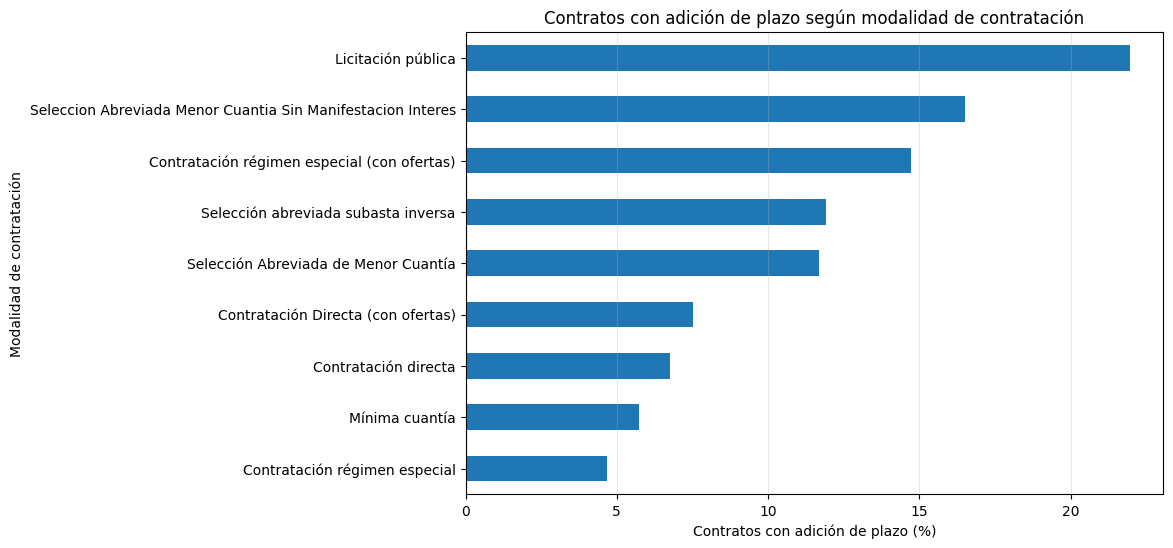

In [48]:
ax = resumen_plazo_modalidad["porcentaje_desviacion"].sort_values().plot(kind="barh", figsize=(9, 6))

plt.title("Contratos con adición de plazo según modalidad de contratación")
plt.xlabel("Contratos con adición de plazo (%)")
plt.ylabel("Modalidad de contratación")
plt.grid(axis="x", alpha=0.3)

plt.show()

Se observan diferencias importantes en la proporción de contratos con adiciones de plazo según la modalidad de contratación. La Licitación pública presenta el porcentaje más alto, con 21.96%, seguida por la Selección Abreviada de Menor Cuantía Sin Manifestación de Interés (16.51%) y la Contratación régimen especial con ofertas (14.72%).

En contraste, las menores proporciones se presentan en Contratación régimen especial (4.67%), Mínima cuantía (5.72.%) y Contratación directa (6.76%). Sin embargo, también es importante considerar el número de contratos de cada modalidad. Por ejemplo, Mínima cuantía presenta una proporción relativamente baja, pero concentra 5.392 contratos con adiciones debido a que es la modalidad con mayor número de observaciones.

#### 4.3.1 Prueba de hipótesis

A partir de las diferencias observadas entre modalidades se plantea:

- H0: la ocurrencia de adiciones de plazo es independiente de la modalidad de contratación.
- H1: la ocurrencia de adiciones de plazo está asociada con la modalidad de contratación.

Dado que ambas variables son categóricas, se utiliza una prueba chi-cuadrado de independencia con un nivel de significancia de 0.05.

In [49]:
tabla_plazo_modalidad = pd.crosstab(df_periodo["modalidad_de_contratacion"], df_periodo["desviacion_plazo"])

display(tabla_plazo_modalidad)

desviacion_plazo,False,True
modalidad_de_contratacion,,
Contratación Directa (con ofertas),3915,318
Contratación directa,2994,217
Contratación régimen especial,13506,662
Contratación régimen especial (con ofertas),4188,723
Licitación pública,1532,431
Mínima cuantía,88857,5392
Seleccion Abreviada Menor Cuantia Sin Manifestacion Interes,177,35
Selección Abreviada de Menor Cuantía,6404,848
Selección abreviada subasta inversa,22968,3111


In [50]:
chi2, p_value, grados_libertad, esperados = stats.chi2_contingency(tabla_plazo_modalidad)

print(f"Chi-cuadrado: {chi2:.4f}")
print(f"Grados de libertad: {grados_libertad}")
print(f"p-value: {p_value:.6f}")
print(f"Frecuencia esperada mínima: {esperados.min():.2f}")

Chi-cuadrado: 2499.1836
Grados de libertad: 8
p-value: 0.000000
Frecuencia esperada mínima: 15.92


Con un nivel de significancia de 0.05, el p-value obtenido es menor que la significancia, por lo que se rechaza la hipótesis nula. Por lo tanto, existe evidencia estadística de una asociación entre la modalidad de contratación y la ocurrencia de adiciones de plazo.

El resultado es consistente con las diferencias observadas descriptivamente entre las modalidades. En particular, algunas modalidades presentan proporciones de adiciones considerablemente superiores a otras. Esta asociación no implica causalidad, sino que la frecuencia de las adiciones de plazo varía según la modalidad de contratación.

### 4.4 Síntesis del análisis de las adiciones de plazo

Los resultados muestran que la ocurrencia de adiciones de plazo presenta diferencias según las tres características contractuales analizadas. En los tres casos, las pruebas chi-cuadrado permiten rechazar la hipótesis de independencia con un nivel de significancia de 0.05.

Descriptivamente, las adiciones son más frecuentes en los contratos de mayor valor, en determinados sectores y en algunas modalidades de contratación. Entre los resultados más destacados, la proporción de contratos con adiciones aumenta de 3% en el primer cuartil de valor a 13.42% en el cuarto, mientras que la Licitación pública alcanza 21.96%.

Estos resultados sugieren que el valor, el sector y la modalidad son características relevantes para identificar grupos de contratos en los que las desviaciones de plazo ocurren con mayor frecuencia.

## 5. Desviación en la ejecución presupuestal

A continuación, se analiza si la frecuencia de contratos cuyo valor pagado es inferior al valor contractual cambia según las características priorizadas en la estrategia.

A diferencia de las adiciones de plazo, este análisis se realiza únicamente sobre el subconjunto de contratos df_cierre. Además, se consideran únicamente contratos con un valor contractual positivo.

In [51]:
df_cierre["rango_valor"] = df_periodo.loc[df_cierre.index, "rango_valor"]

In [52]:
df_cierre["rango_valor"].value_counts().sort_index()

rango_valor
Q1 - Menor valor    38669
Q2                  38585
Q3                  37919
Q4 - Mayor valor    36173
Name: count, dtype: int64

In [53]:
df_presupuesto = df_cierre.loc[df_cierre["valor_contrato_valido"]].copy()

### 5.1 Desviación presupuestal según el valor del contrato

En primer lugar, se compara la proporción de contratos que presentan desviación en la ejecución presupuestal entre los cuatro rangos de valor contractual.

In [54]:
resumen_presupuesto_valor = (
    df_presupuesto
    .dropna(subset=["rango_valor"])
    .groupby("rango_valor", observed=True)["desviacion_presupuesto"]
    .agg(
        cantidad_contratos="size",
        contratos_con_desviacion="sum",
        porcentaje_desviacion=lambda x: x.mean() * 100
    )
)

display(resumen_presupuesto_valor.style.format({"porcentaje_desviacion": "{:.2f}%"}))

,cantidad_contratos,contratos_con_desviacion,porcentaje_desviacion
rango_valor,,,
Q1 - Menor valor,38669,26889,69.54%
Q2,38585,27244,70.61%
Q3,37919,28303,74.64%
Q4 - Mayor valor,36173,29132,80.54%


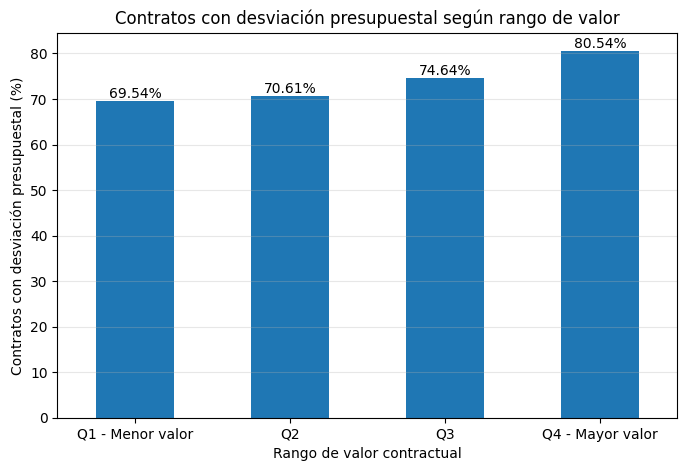

In [57]:
ax = resumen_presupuesto_valor["porcentaje_desviacion"].plot(kind="bar", figsize=(8, 5))

plt.title("Contratos con desviación presupuestal según rango de valor")
plt.xlabel("Rango de valor contractual")
plt.ylabel("Contratos con desviación presupuestal (%)")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.show()

Se observa un aumento progresivo en la proporción de contratos con desviación presupuestal a medida que aumenta el rango de valor contractual. En el primer cuartil, el 69.54% de los contratos presenta un valor pagado inferior al valor contractual, mientras que esta proporción aumenta a 70.61% en Q2, 74.64% en Q3 y 80.54% en el grupo de contratos de mayor valor.

Aunque la desviación presupuestal es frecuente en todos los rangos, descriptivamente los contratos de mayor valor presentan esta condición con mayor frecuencia.

#### 5.1.1 Prueba de hipótesis

Para determinar si existe evidencia estadística de una dependencia entre ambas variables se plantean las siguientes hipótesis:

- H0: la ocurrencia de desviación presupuestal es independiente del rango de valor del contrato.
- H1: la ocurrencia de desviación presupuestal está asociada con el rango de valor del contrato.

Dado que ambas variables son categóricas, se utiliza una prueba chi-cuadrado de independencia con un nivel de significancia de 0.05.

In [58]:
tabla_presupuesto_valor = pd.crosstab(df_presupuesto["rango_valor"], df_presupuesto["desviacion_presupuesto"])

display(tabla_presupuesto_valor)

desviacion_presupuesto,False,True
rango_valor,,
Q1 - Menor valor,11780,26889
Q2,11341,27244
Q3,9616,28303
Q4 - Mayor valor,7041,29132


In [59]:
chi2, p_value, grados_libertad, esperados = stats.chi2_contingency(tabla_presupuesto_valor)

print(f"Chi-cuadrado: {chi2:.4f}")
print(f"Grados de libertad: {grados_libertad}")
print(f"p-value: {p_value:.6f}")
print(f"Frecuencia esperada mínima: {esperados.min():.2f}")

Chi-cuadrado: 1425.9842
Grados de libertad: 3
p-value: 0.000000
Frecuencia esperada mínima: 9507.29


Con un nivel de significancia de 0.05, el p-value obtenido es menor que la significancia, por lo que se rechaza la hipótesis nula. Por lo tanto, existe evidencia estadística de una asociación entre el rango de valor contractual y la ocurrencia de desviación presupuestal.

Este resultado coincide con el análisis descriptivo, en el que la proporción de contratos con desviación aumenta desde 69.54% en Q1 hasta 80.54% en Q4. La asociación encontrada no implica que un mayor valor contractual cause una menor ejecución presupuestal, sino que la frecuencia de esta condición difiere entre los rangos de valor.

### 5.2 Desviación presupuestal según el sector

A continuación, se analiza si la proporción de contratos con desviación en la ejecución presupuestal cambia entre los diferentes sectores.

Al igual que en el análisis anterior por sector, se excluye la categoría No Definido, ya que no corresponde a un sector específico.

In [60]:
df_presupuesto_sector = df_presupuesto.loc[df_presupuesto["sector"] != "No Definido"].copy()

resumen_presupuesto_sector = (
    df_presupuesto_sector
    .groupby("sector")["desviacion_presupuesto"]
    .agg(
        cantidad_contratos="size",
        contratos_con_desviacion="sum",
        porcentaje_desviacion=lambda x: x.mean() * 100
    )
    .sort_values("porcentaje_desviacion", ascending=False)
)

display(resumen_presupuesto_sector.style.format({"porcentaje_desviacion": "{:.2f}%"}))

,cantidad_contratos,contratos_con_desviacion,porcentaje_desviacion
sector,,,
Inteligencia Estratégica y Contrainteligencia,81,81,100.00%
Relaciones Exteriores,282,276,97.87%
Salud y Protección Social,16714,14644,87.62%
agricultura,987,847,85.82%
Transporte,3480,2911,83.65%
Minas y Energía,802,661,82.42%
interior,958,779,81.32%
Inclusión Social y Reconciliación,691,561,81.19%
Industria,1335,1057,79.18%


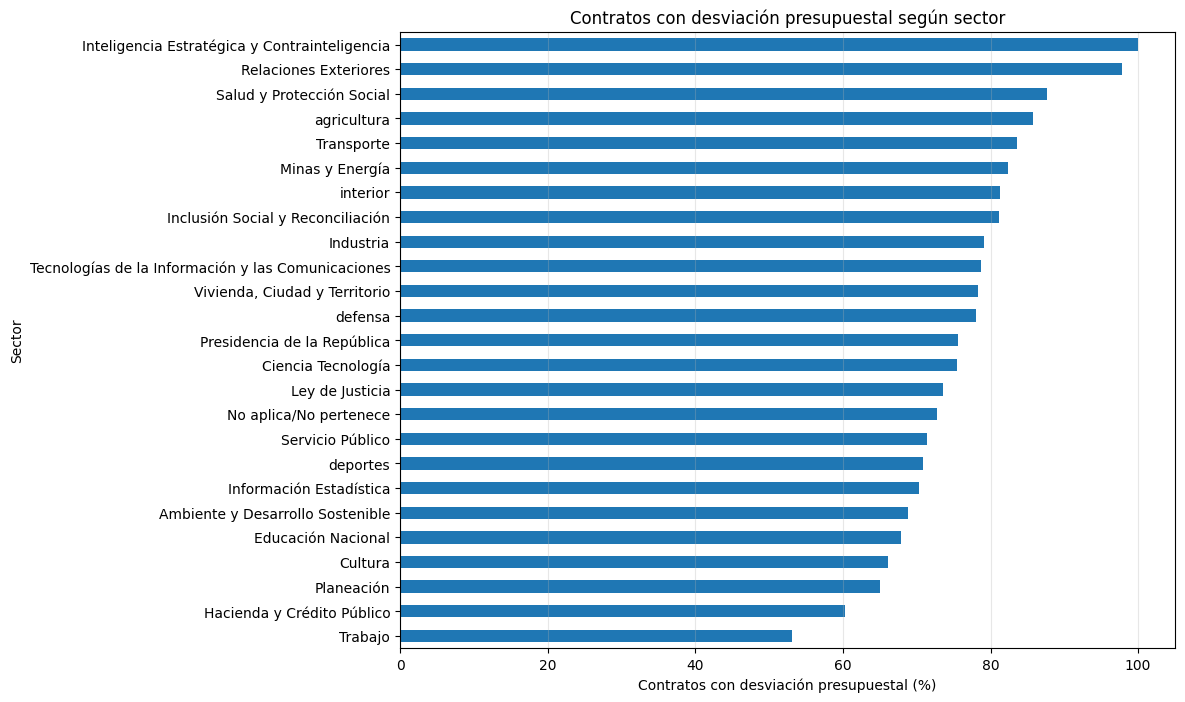

In [61]:
resumen_presupuesto_sector["porcentaje_desviacion"].sort_values().plot(kind="barh", figsize=(10, 8))

plt.title("Contratos con desviación presupuestal según sector")
plt.xlabel("Contratos con desviación presupuestal (%)")
plt.ylabel("Sector")
plt.grid(axis="x", alpha=0.3)

plt.show()

Se observan diferencias importantes en la proporción de contratos con desviación presupuestal entre los distintos sectores. Los mayores porcentajes se presentan en Inteligencia Estratégica y Contrainteligencia (100.00%), Relaciones Exteriores (97.87%) y Salud y Protección Social (87.62%).

En contraste, los menores porcentajes corresponden a Trabajo (53.08%), Hacienda y Crédito Público (60.31%) y Planeación (64.98%). Sin embargo, estas proporciones deben interpretarse junto con el número de contratos de cada sector. Por ejemplo, Inteligencia Estratégica y Contrainteligencia presenta el porcentaje más alto, pero cuenta con solo
81 contratos, mientras que sectores como Salud y Protección Social, defensa y Servicio Público combinan porcentajes elevados con un número considerablemente mayor de contratos.

#### 5.2.1 Prueba de hipótesis

Para determinar si las diferencias observadas entre sectores presentan evidencia estadística de una dependencia, se plantean:

- H0: la ocurrencia de desviación presupuestal es independiente del sector.
- H1: la ocurrencia de desviación presupuestal está asociada con el sector.

Dado que ambas variables son categóricas, se utiliza una prueba chi-cuadrado de independencia con un nivel de significancia de 0.05.

In [62]:
tabla_presupuesto_sector = pd.crosstab(df_presupuesto_sector["sector"], df_presupuesto_sector["desviacion_presupuesto"])

display(tabla_presupuesto_sector)

desviacion_presupuesto,False,True
sector,,
Ambiente y Desarrollo Sostenible,2050,4534
Ciencia Tecnología,84,258
Cultura,739,1446
Educación Nacional,2476,5236
Hacienda y Crédito Público,783,1190
Inclusión Social y Reconciliación,130,561
Industria,278,1057
Información Estadística,120,284
Inteligencia Estratégica y Contrainteligencia,0,81


In [63]:
chi2, p_value, grados_libertad, esperados = stats.chi2_contingency(tabla_presupuesto_sector)

print(f"Chi-cuadrado: {chi2:.4f}")
print(f"Grados de libertad: {grados_libertad}")
print(f"p-value: {p_value:.6f}")
print(f"Frecuencia esperada mínima: {esperados.min():.2f}")

Chi-cuadrado: 5522.3166
Grados de libertad: 24
p-value: 0.000000
Frecuencia esperada mínima: 21.29


Con un nivel de significancia de 0.05, el p-value obtenido es menor que la significancia, por lo
que se rechaza la hipótesis nula. Por lo tanto, existe evidencia estadística de una asociación entre el sector y la ocurrencia de desviación presupuestal.

El resultado es consistente con las diferencias observadas descriptivamente entre los sectores. Sin embargo, esta asociación no implica que pertenecer a un determinado sector cause una menor ejecución presupuestal; indica que la frecuencia de esta desviación varía entre los diferentes sectores analizados.

### 5.3 Desviación presupuestal según la modalidad de contratación

Finalmente, se analiza si la frecuencia de contratos con desviación en la ejecución presupuestal cambia entre las distintas modalidades de contratación.

In [64]:
resumen_presupuesto_modalidad = (
    df_presupuesto
    .groupby("modalidad_de_contratacion")["desviacion_presupuesto"]
    .agg(
        cantidad_contratos="size",
        contratos_con_desviacion="sum",
        porcentaje_desviacion=lambda x: x.mean() * 100
    )
    .sort_values("porcentaje_desviacion", ascending=False)
)

display(resumen_presupuesto_modalidad.style.format({"porcentaje_desviacion": "{:.2f}%"}))

,cantidad_contratos,contratos_con_desviacion,porcentaje_desviacion
modalidad_de_contratacion,,,
Contratación régimen especial (con ofertas),4414,4145,93.91%
Contratación régimen especial,13755,11619,84.47%
Licitación pública,1701,1375,80.83%
Contratación directa,3114,2467,79.22%
Selección Abreviada de Menor Cuantía,6935,5459,78.72%
Selección abreviada subasta inversa,24554,19154,78.01%
Seleccion Abreviada Menor Cuantia Sin Manifestacion Interes,190,144,75.79%
Mínima cuantía,92646,64504,69.62%
Contratación Directa (con ofertas),4037,2701,66.91%


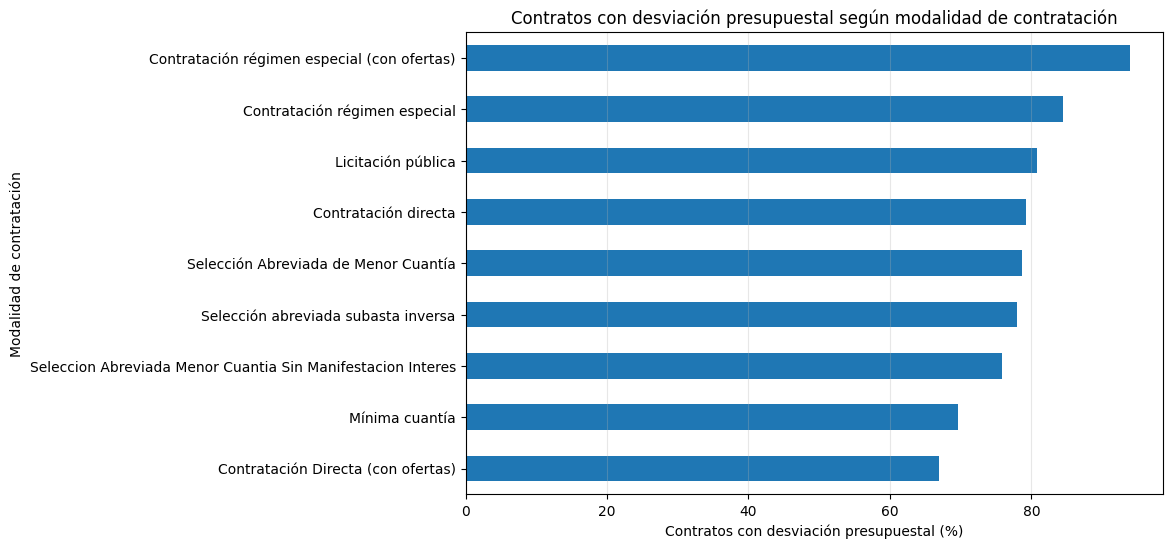

In [66]:
resumen_presupuesto_modalidad["porcentaje_desviacion"].sort_values().plot(kind="barh", figsize=(9, 6))

plt.title("Contratos con desviación presupuestal según modalidad de contratación")
plt.xlabel("Contratos con desviación presupuestal (%)")
plt.ylabel("Modalidad de contratación")
plt.grid(axis="x", alpha=0.3)

plt.show()

Se observan diferencias en la proporción de contratos con desviación presupuestal según la modalidad de contratación. La mayor proporción se presenta en Contratación régimen especial con ofertas (93.91%), seguida por Contratación régimen especial (84.47%) y Licitación pública (80.83%).

Las menores proporciones corresponden a Contratación Directa con ofertas (66.91%) y Mínima cuantía (69.62%). Sin embargo, la cantidad de contratos también debe tenerse en cuenta. Por ejemplo, Mínima cuantía presenta una proporción menor que otras modalidades, pero concentra 64504 contratos con desviación debido a que representa la mayor cantidad de observaciones del conjunto analizado.

#### 5.3.1 Prueba de hipótesis

Se plantean las siguientes hipótesis:

- H0: la ocurrencia de desviación presupuestal es independiente de la modalidad de contratación.
- H1: la ocurrencia de desviación presupuestal está asociada con la modalidad de contratación.

Se utiliza una prueba chi-cuadrado de independencia con un nivel de significancia de 0.05.

In [67]:
tabla_presupuesto_modalidad = pd.crosstab(df_presupuesto["modalidad_de_contratacion"], df_presupuesto["desviacion_presupuesto"])

display(tabla_presupuesto_modalidad)

desviacion_presupuesto,False,True
modalidad_de_contratacion,,
Contratación Directa (con ofertas),1336,2701
Contratación directa,647,2467
Contratación régimen especial,2136,11619
Contratación régimen especial (con ofertas),269,4145
Licitación pública,326,1375
Mínima cuantía,28142,64504
Seleccion Abreviada Menor Cuantia Sin Manifestacion Interes,46,144
Selección Abreviada de Menor Cuantía,1476,5459
Selección abreviada subasta inversa,5400,19154


In [68]:
chi2, p_value, grados_libertad, esperados = stats.chi2_contingency(tabla_presupuesto_modalidad)

print(f"Chi-cuadrado: {chi2:.4f}")
print(f"Grados de libertad: {grados_libertad}")
print(f"p-value: {p_value:.6f}")
print(f"Frecuencia esperada mínima: {esperados.min():.2f}")

Chi-cuadrado: 3063.6712
Grados de libertad: 8
p-value: 0.000000
Frecuencia esperada mínima: 49.94


Con un nivel de significancia de 0.05, el p-value obtenido es menor que la significancia, por lo que se rechaza la hipótesis nula. Por lo tanto, existe evidencia estadística de una asociación entre la modalidad de contratación y la ocurrencia de desviación presupuestal.

Este resultado es consistente con las diferencias observadas en el análisis descriptivo. La asociación encontrada no implica que la modalidad de contratación cause una menor ejecución presupuestal, sino que la frecuencia de esta desviación difiere entre las modalidades analizadas.

### 5.4 Síntesis del análisis de la desviación presupuestal

Los resultados muestran que la desviación presupuestal presenta diferencias según el valor del contrato, el sector y la modalidad de contratación. En los tres análisis, las pruebas chi-cuadrado permiten rechazar la hipótesis de independencia con un nivel de significancia de 0,05.

Descriptivamente, la desviación presupuestal es frecuente en todos los grupos analizados, pero su ocurrencia aumenta con el valor contractual, pasando de 69.54% en el primer cuartil a 80.54% en el cuarto. También se observan diferencias importantes entre sectores y modalidades. Por ejemplo, Salud y Protección Social presenta una proporción de 87.62%, mientras que Trabajo presenta 53.08%. Por modalidad, Contratación régimen especial con ofertas alcanza 93.91%, frente a 66.91% en Contratación Directa con ofertas.

Estos resultados sugieren que el valor, el sector y la modalidad de contratación son características relevantes para identificar grupos en los que la ejecución incompleta del valor comprometido ocurre con mayor frecuencia.

## 6. Análisis de la desviación de liquidación

Finalmente, se analiza si la ausencia de liquidación entre los contratos cuyo período previsto de ejecución ya había finalizado cambia según las características contractuales priorizadas en la estrategia.

Al igual que en el análisis presupuestal, se utiliza el subconjunto df_cierre, que contiene contratos suficientemente avanzados en su ciclo contractual y con fechas consistentes.

### 6.1 Desviación de liquidación según el valor del contrato

En primer lugar, se compara la proporción de contratos con desviación de liquidación
entre los cuatro rangos de valor contractual.

In [70]:
resumen_liquidacion_valor = (
    df_cierre
    .dropna(subset=["rango_valor"])
    .groupby("rango_valor", observed=True)["desviacion_liquidacion"]
    .agg(
        cantidad_contratos="size",
        contratos_con_desviacion="sum",
        porcentaje_desviacion=lambda x: x.mean() * 100
    )
)

display(resumen_liquidacion_valor.style.format({"porcentaje_desviacion": "{:.2f}%"}))

,cantidad_contratos,contratos_con_desviacion,porcentaje_desviacion
rango_valor,,,
Q1 - Menor valor,38669,27387,70.82%
Q2,38585,24965,64.70%
Q3,37919,22939,60.49%
Q4 - Mayor valor,36173,19742,54.58%


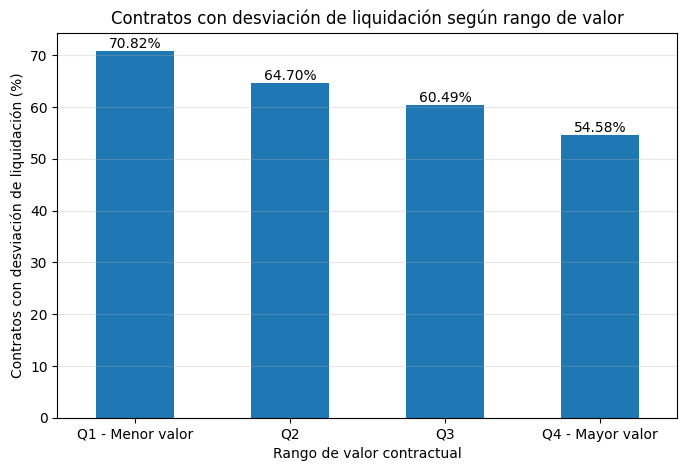

In [71]:
ax = resumen_liquidacion_valor["porcentaje_desviacion"].plot(kind="bar", figsize=(8, 5))

plt.title("Contratos con desviación de liquidación según rango de valor")
plt.xlabel("Rango de valor contractual")
plt.ylabel("Contratos con desviación de liquidación (%)")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.show()

Se observa una disminución progresiva en la proporción de contratos con desviación de liquidación a medida que aumenta el rango de valor contractual. En el primer cuartil, el 70.82% de los contratos no registra liquidación, mientras que esta proporción disminuye a 64.70% en Q2, 60.49% en Q3 y 54.58% en el grupo de contratos de mayor valor.

Descriptivamente, esto indica que la ausencia de liquidación es más frecuente entre los contratos de menor valor. Este comportamiento es diferente al observado para las desviaciones de plazo y presupuesto, cuya frecuencia aumentaba con el valor contractual.

#### 6.1.1 Prueba de hipótesis

Se plantean las siguientes hipótesis:

- H0: la ocurrencia de desviación de liquidación es independiente del rango de valor del contrato.
- H1: la ocurrencia de desviación de liquidación está asociada con el rango de valor del contrato.

Dado que ambas variables son categóricas, se utiliza una prueba chi-cuadrado de independencia con un nivel de significancia de 0.05.

In [72]:
tabla_liquidacion_valor = pd.crosstab(df_cierre["rango_valor"], df_cierre["desviacion_liquidacion"])

display(tabla_liquidacion_valor)

desviacion_liquidacion,False,True
rango_valor,,
Q1 - Menor valor,11282,27387
Q2,13620,24965
Q3,14980,22939
Q4 - Mayor valor,16431,19742


In [73]:
chi2, p_value, grados_libertad, esperados = stats.chi2_contingency(tabla_liquidacion_valor)

print(f"Chi-cuadrado: {chi2:.4f}")
print(f"Grados de libertad: {grados_libertad}")
print(f"p-value: {p_value:.6f}")
print(f"Frecuencia esperada mínima: {esperados.min():.2f}")

Chi-cuadrado: 2258.6097
Grados de libertad: 3
p-value: 0.000000
Frecuencia esperada mínima: 13459.29


Con un nivel de significancia de 0.05, el p-value obtenido es menor que la significancia, por lo que se rechaza la hipótesis nula. Por lo tanto, existe evidencia estadística de una asociación entre el rango de valor contractual y la ocurrencia de desviación de liquidación.

El resultado es consistente con el análisis descriptivo, en el que la proporción de contratos sin liquidación disminuye desde 70.82% en el rango de menor valor hasta 54.58% en el rango de mayor valor. Esta asociación no implica que el valor contractual determine la liquidación del contrato.

### 6.2 Desviación de liquidación según el sector

A continuación, se analiza si la proporción de contratos con desviación de liquidación cambia entre los diferentes sectores. Al igual que en los análisis anteriores, se excluye la categoría No Definido.

In [75]:
df_liquidacion_sector = df_cierre.loc[df_cierre["sector"] != "No Definido"].copy()

resumen_liquidacion_sector = (
    df_liquidacion_sector
    .groupby("sector")["desviacion_liquidacion"]
    .agg(
        cantidad_contratos="size",
        contratos_con_desviacion="sum",
        porcentaje_desviacion=lambda x: x.mean() * 100
    )
    .sort_values("porcentaje_desviacion", ascending=False)
)

display(resumen_liquidacion_sector.style.format({"porcentaje_desviacion": "{:.2f}%"}))

,cantidad_contratos,contratos_con_desviacion,porcentaje_desviacion
sector,,,
interior,959,820,85.51%
Ciencia Tecnología,342,290,84.80%
Ley de Justicia,17681,14053,79.48%
Presidencia de la República,774,611,78.94%
Minas y Energía,802,612,76.31%
agricultura,990,743,75.05%
deportes,2042,1509,73.90%
Educación Nacional,7742,5598,72.31%
Salud y Protección Social,16724,12053,72.07%


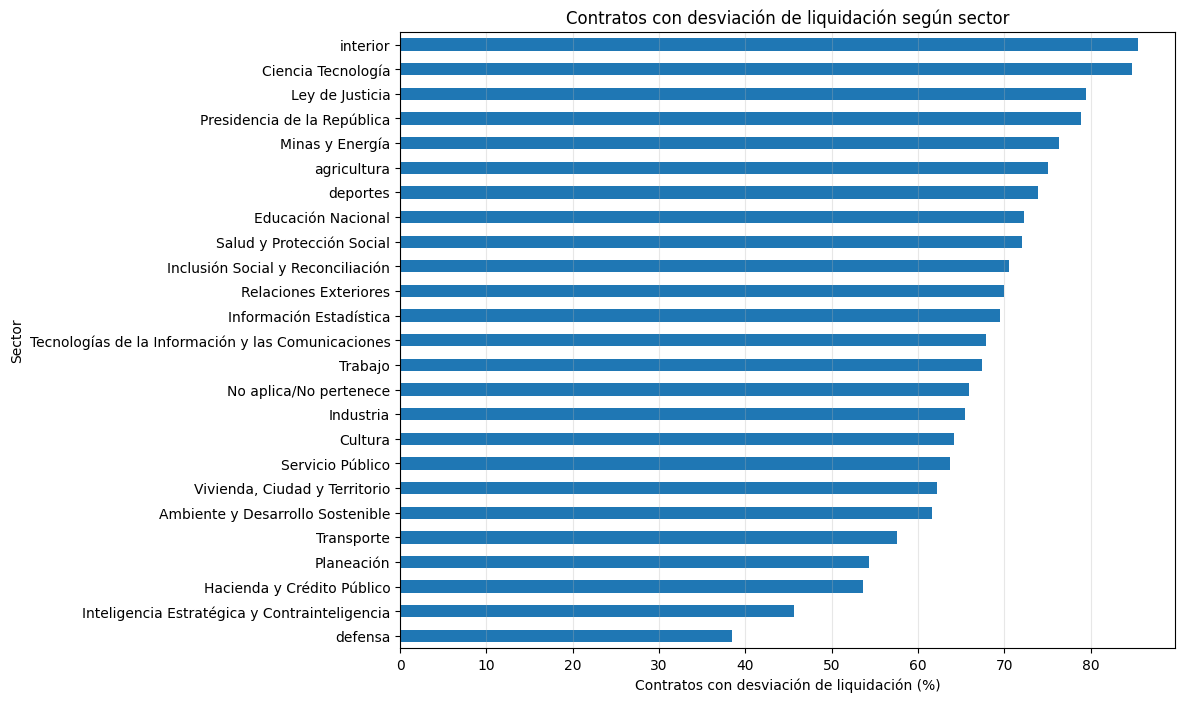

In [76]:
resumen_liquidacion_sector["porcentaje_desviacion"].sort_values().plot(kind="barh", figsize=(10, 8))

plt.title("Contratos con desviación de liquidación según sector")
plt.xlabel("Contratos con desviación de liquidación (%)")
plt.ylabel("Sector")
plt.grid(axis="x", alpha=0.3)

plt.show()

Se observan diferencias importantes en la proporción de contratos con desviación de liquidación entre los sectores. Los mayores porcentajes se presentan en interior (85.51%), Ciencia Tecnología (84.80%) y Ley de Justicia (79.48%).

En contraste, los menores porcentajes corresponden a defensa (38.47%), Inteligencia Estratégica y Contrainteligencia (45.68%) y Hacienda y Crédito Público (53.62%). Sin embargo, estas proporciones deben interpretarse junto con la cantidad de contratos de cada sector. Por ejemplo, Ciencia Tecnología e Inteligencia Estratégica y Contrainteligencia tienen relativamente pocas observaciones, mientras que defensa y Ley de Justicia reúnen un número considerablemente mayor de contratos.

#### 6.2.1 Prueba de hipótesis

- H0: la ocurrencia de desviación de liquidación es independiente del sector.
- H1: la ocurrencia de desviación de liquidación está asociada con el sector.

Se utiliza una prueba chi-cuadrado de independencia con un nivel de significancia de 0.05.

In [77]:
tabla_liquidacion_sector = pd.crosstab(df_liquidacion_sector["sector"], df_liquidacion_sector["desviacion_liquidacion"])

chi2, p_value, grados_libertad, esperados = stats.chi2_contingency(tabla_liquidacion_sector)

print(f"Chi-cuadrado: {chi2:.4f}")
print(f"Grados de libertad: {grados_libertad}")
print(f"p-value: {p_value:.6f}")
print(f"Frecuencia esperada mínima: {esperados.min():.2f}")

Chi-cuadrado: 11388.6696
Grados de libertad: 24
p-value: 0.000000
Frecuencia esperada mínima: 30.16


Con un nivel de significancia de 0.05, el p-value obtenido es menor que la significancia, por lo que se rechaza la hipótesis nula. Por lo tanto, existe evidencia estadística de una asociación entre el sector y la ocurrencia de desviación de liquidación.

El resultado respalda las diferencias observadas descriptivamente entre los sectores. Sin embargo, esta asociación no implica que el sector cause la ausencia de liquidación, sino que la frecuencia de esta condición varía entre los sectores analizados.

### 6.3 Desviación de liquidación según la modalidad

Finalmente, se analiza si la frecuencia de contratos con desviación de liquidación cambia según la modalidad de contratación.

In [78]:
resumen_liquidacion_modalidad = (
    df_cierre
    .groupby("modalidad_de_contratacion")["desviacion_liquidacion"]
    .agg(
        cantidad_contratos="size",
        contratos_con_desviacion="sum",
        porcentaje_desviacion=lambda x: x.mean() * 100
    )
    .sort_values("porcentaje_desviacion", ascending=False)
)

display(resumen_liquidacion_modalidad.style.format({"porcentaje_desviacion": "{:.2f}%"}))

,cantidad_contratos,contratos_con_desviacion,porcentaje_desviacion
modalidad_de_contratacion,,,
Contratación régimen especial (con ofertas),4414,3531,80.00%
Contratación régimen especial,13789,10148,73.59%
Contratación directa,3153,2277,72.22%
Mínima cuantía,92708,59101,63.75%
Contratación Directa (con ofertas),4043,2201,54.44%
Selección abreviada subasta inversa,24558,13196,53.73%
Selección Abreviada de Menor Cuantía,6938,3706,53.42%
Licitación pública,1702,863,50.71%
Seleccion Abreviada Menor Cuantia Sin Manifestacion Interes,190,67,35.26%


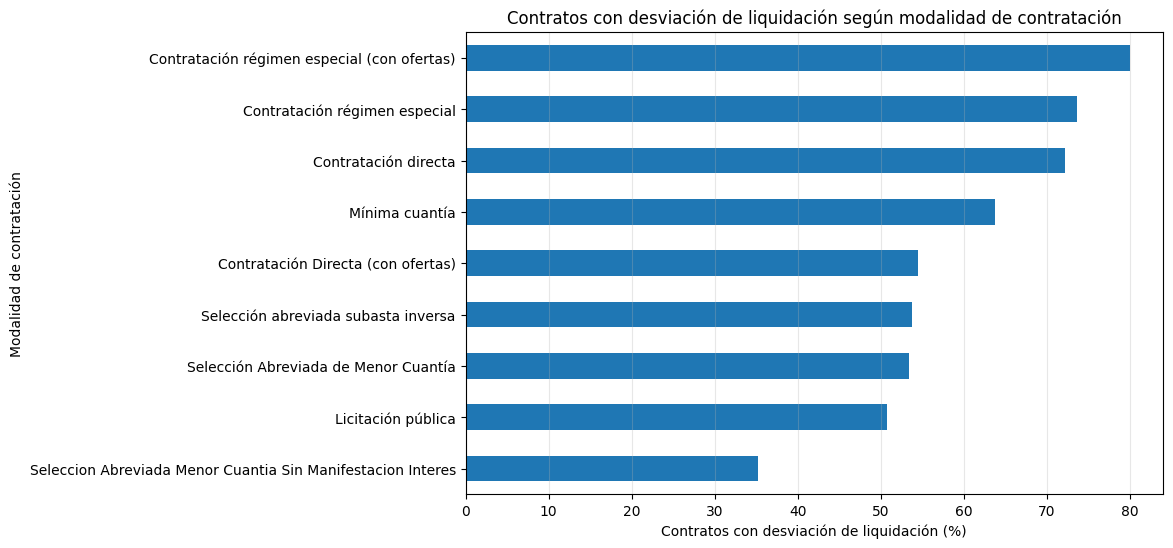

In [79]:
resumen_liquidacion_modalidad["porcentaje_desviacion"].sort_values().plot(kind="barh", figsize=(9, 6))

plt.title("Contratos con desviación de liquidación según modalidad de contratación")
plt.xlabel("Contratos con desviación de liquidación (%)")
plt.ylabel("Modalidad de contratación")
plt.grid(axis="x", alpha=0.3)

plt.show()

Se observan diferencias en la proporción de contratos con desviación de liquidación según la modalidad de contratación. La mayor proporción corresponde a Contratación régimen especial con ofertas (80.00%), seguida por Contratación régimen especial (73.59%) y Contratación directa (72.22%).

Las menores proporciones se presentan en Selección Abreviada de Menor Cuantía Sin Manifestación de Interés (35.26%), Licitación pública (50.71%) y Selección Abreviada de Menor Cuantía (53.42%). No obstante, debe considerarse el tamaño de cada grupo: la primera de estas modalidades contiene solamente 190 contratos, mientras que Mínima cuantía, con una proporción de 63.75%, concentra más de 92000 contratos.

#### 6.3.1 Prueba de hipótesis

- H0: la ocurrencia de desviación de liquidación es independiente de la modalidad de contratación.
- H1: la ocurrencia de desviación de liquidación está asociada con la modalidad de contratación.

Se utiliza una prueba chi-cuadrado de independencia con un nivel de significancia de 0.05.

In [80]:
tabla_liquidacion_modalidad = pd.crosstab(df_cierre["modalidad_de_contratacion"], df_cierre["desviacion_liquidacion"])

chi2, p_value, grados_libertad, esperados = stats.chi2_contingency(tabla_liquidacion_modalidad)

print(f"Chi-cuadrado: {chi2:.4f}")
print(f"Grados de libertad: {grados_libertad}")
print(f"p-value: {p_value:.6f}")
print(f"Frecuencia esperada mínima: {esperados.min():.2f}")

Chi-cuadrado: 2815.6340
Grados de libertad: 8
p-value: 0.000000
Frecuencia esperada mínima: 70.74


Con un nivel de significancia de 0.05, el p-value obtenido es menor que la significancia, por lo que se rechaza la hipótesis nula. Por lo tanto, existe evidencia estadística de una asociación entre la modalidad de contratación y la ocurrencia de desviación de liquidación.

Este resultado es consistente con las diferencias observadas descriptivamente entre las modalidades. La asociación encontrada no implica causalidad, sino que la frecuencia de ausencia de liquidación difiere entre las modalidades analizadas.

### 6.4 Síntesis del análisis de la desviación de liquidación

Los resultados muestran que la desviación de liquidación presenta diferencias según el valor contractual, el sector y la modalidad de contratación. En los tres análisis, las pruebas chi-cuadrado permiten rechazar la hipótesis de independencia con un nivel de significancia de 0.05.

A diferencia de las desviaciones de plazo y presupuesto, la ausencia de liquidación disminuye conforme aumenta el valor contractual: pasa de 70.82% en el primer cuartil a 54.58% en el cuarto. También se observan diferencias importantes según sector y modalidad. Por ejemplo, interior presenta una proporción de 85.51%, frente a 38.47% en defensa, mientras que por modalidad la Contratación régimen especial con ofertas alcanza 80.00%.

Estos resultados sugieren que el valor, el sector y la modalidad también son características relevantes para identificar grupos en los que la ausencia de liquidación ocurre con mayor frecuencia.

## 7. Síntesis integrada de resultados

Después de analizar las tres desviaciones consideradas en el problema (adiciones de plazo, ejecución presupuestal incompleta y ausencia de liquidación) se integran los principales resultados obtenidos para el valor contractual, el sector y la modalidad de contratación.

En total se contrastaron nueve hipótesis de independencia. En todas las pruebas se obtuvo un p-value inferior al nivel de significancia de 0.05, por lo que se rechazó la hipótesis nula en cada caso. Por tanto, dentro de las comparaciones realizadas no se obtuvieron resultados estadísticamente no significativos.

### 7.1 Resumen de pruebas de hipótesis

| Desviación | Característica analizada | Chi-cuadrado | gl | p-value | Decisión |
|---|---|---:|---:|---:|---|
| Plazo | Rango de valor | 3323,24 | 3 | < 0,001 | Se rechaza H0 |
| Plazo | Sector | 1011,02 | 24 | < 0,001 | Se rechaza H0 |
| Plazo | Modalidad | 2499,18 | 8 | < 0,001 | Se rechaza H0 |
| Presupuesto | Rango de valor | 1425,98 | 3 | < 0,001 | Se rechaza H0 |
| Presupuesto | Sector | 5522,32 | 24 | < 0,001 | Se rechaza H0 |
| Presupuesto | Modalidad | 3063,67 | 8 | < 0,001 | Se rechaza H0 |
| Liquidación | Rango de valor | 2258,61 | 3 | < 0,001 | Se rechaza H0 |
| Liquidación | Sector | 11388,67 | 24 | < 0,001 | Se rechaza H0 |
| Liquidación | Modalidad | 2815,63 | 8 | < 0,001 | Se rechaza H0 |

### 7.2 Insights integrados

El análisis muestra que las tres características estudiadas (valor contractual, sector y modalidad de contratación) están asociadas con las desviaciones consideradas. Sin embargo, los patrones no son iguales para todos los tipos de desviación.

En relación con el valor contractual, los contratos de mayor valor presentan con mayor frecuencia adiciones de plazo y desviaciones presupuestales. La proporción de contratos con adiciones aumenta de 3.00% en Q1 a 13.42% en Q4, mientras que la desviación presupuestal aumenta de 69.54% a 80.54%. En cambio, la ausencia de liquidación presenta el comportamiento contrario, disminuyendo de 70.82% en Q1 a 54.58% en Q4. Por tanto, un mayor valor contractual no está asociado de la misma manera con todas las desviaciones.

La modalidad de contratación también presenta comportamientos diferentes según la desviación observada. La Licitación pública registra la mayor proporción de adiciones de plazo (21.96%), mientras que la Contratación régimen especial con ofertas presenta las mayores proporciones de desviación presupuestal (93.91%) y de ausencia de liquidación (80.00%). Esto indica que las modalidades que destacan en una desviación no necesariamente son las mismas que destacan en otra.

El comportamiento por sector también depende del tipo de desviación. Por ejemplo, Trabajo presenta una de las mayores proporciones de adiciones de plazo (13.23%), pero la menor proporción de desviación presupuestal (53.08%). Por otra parte, defensa presenta una proporción relativamente baja de ausencia de liquidación (38.47%), aunque su desviación presupuestal alcanza 78.04%. Estos resultados muestran que no resulta adecuado caracterizar un sector como problemático de manera general sin especificar qué tipo de desviación se está analizando.

También es importante diferenciar entre la proporción de desviaciones y su volumen absoluto. Algunas categorías presentan porcentajes relativamente bajos, pero concentran una gran cantidad de contratos. Por ejemplo, Mínima cuantía presenta porcentajes menores que otras modalidades en varias de las desviaciones, pero debido al elevado número de contratos que concentra representa una cantidad considerable de casos con desviación. Por ello, tanto la frecuencia relativa como el número de contratos deben considerarse al interpretar los resultados.

### 7.3 Cierre del desarrollo

En conjunto, los resultados proporcionan evidencia de que el valor del contrato, el sector y la modalidad de contratación contienen información útil para diferenciar grupos de contratos con distintas frecuencias de desviación. No obstante, las asociaciones encontradas son descriptivas y estadísticas y no deben interpretarse como relaciones causales.

Estos hallazgos constituyen la base para definir posteriormente criterios de focalización de la supervisión, teniendo en cuenta que las características relevantes y su dirección cambian dependiendo del tipo de desviación que se quiera prevenir o monitorear.